In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os


os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")

import diagnostic_plot_helper as dps  
from scipy.special import gamma
import gc
import cartopy.crs as ccrs

def get_global_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    return time_2D_avg

def decomp_term_time_2D_vert(term,area,phalf,ps,temp):
    # term is (time,pfull,lat,lon)
    vert_avg = dps.vertical_int_z(term,temp, phalf,ps) # (time,lat,lon)
    vert_2D_avg = dps.area_w_avg(area, vert_avg, D3=True) # (time)
    time_vert_2D_avg = np.mean(vert_2D_avg,axis = 0)
    
    prime = term - time_vert_2D_avg
    return term,time_vert_2D_avg,prime

def decomp_term_time_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    
    prime = term - time_2D_avg
    return term,time_2D_avg,prime

def decomp_term_time(term):
    # term is (time,pfull,lat,lon)

    time_avg = term.mean(dim = "time")
    
    prime = term - time_avg
    return term,time_avg,prime

def get_eddy_kin_energy(ucomp,vcomp):
    u,global_u,u_prime = decomp_term_time(ucomp)
    v,global_v,v_prime = decomp_term_time(vcomp)
    uterm = (u_prime**2).mean(dim = "time",keepdims=True)
    vterm = (v_prime**2).mean(dim = "time",keepdims=True)
    return 0.5* (uterm + vterm)

def gamma_dist(x,mean,mom2):
    theta = (mom2-mean**2)/(mean)
    alpha = mean/theta
    num = x**(alpha -1) * np.exp(-x/theta)
    den = gamma(alpha) * theta**alpha
    return num/den

def weibull_dist(x,mean,mom2):
    std = np.sqrt(mom2-mean**2)
    b_ = (mean/std)**1.086
    a_ = mean/(gamma(1+1/b_))
    return (b_/a_)*(x/a_)**(b_-1)*np.exp(-(x/a_)**b_)

def get_alpha_theta(mean,mom2):
    theta = (mom2-mean**2)/(mean)
    alpha = mean/theta
    return alpha, theta

def get_a_b(mean,mom2):
    std = np.sqrt(mom2-mean**2)
    b_ = (mean/std)**1.086
    a_ = mean/(gamma(1+1/b_))
    return a_, b_

def get_n_moment_weib(a,b,n):
    return a**n * gamma(1 + (n/b))

def get_n_moment_gamma(alpha, theta, n):
    return theta**n * gamma(alpha+n)/gamma(alpha)

path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"

land_mask_name = "era_land_t85.nc"
land_bool = True
if land_bool:
    lm_path = "~/Isca/exp/test_cases/realistic_continents/input/"+land_mask_name
    ds_landmask = xr.open_dataset(lm_path) 
    land_mask = ds_landmask.land_mask.values
    
plt.rcParams['text.usetex'] = True

# Load and process datasets
delta_sst_values = np.array([0])
ds_dict = {}
i=0
for delta_sst in delta_sst_values:
    path_folder = "~/projects/def-rfajber/philbou/saved_ds/"
    #path_folder = "./"
    base_folder_name = "RT85_sst_"


    exp_folder_name = f"{base_folder_name}dt"
    path = f"{path_folder}/{exp_folder_name}"

    ds_age = xr.open_dataset(f"{path}/age.nc")
    ds_mix = xr.open_dataset(f"{path}/mixed_layer.nc",decode_times = False)
    ds_dyn = xr.open_dataset(f"{path}/dynamics.nc")
    #ds_precip_age = xr.open_dataset(f"{path}/precipitation_age.nc")
    #ds_rad = xr.open_dataset(f"{path}/rrtm_rad.nc")
    
    ds_age["time"] = np.arange(0,len(ds_age.time.values),1)
    ds_dyn["time"] = np.arange(0,len(ds_dyn.time.values),1)
    #ds_rad["time"] = np.arange(0,len(ds_rad.time.values),1)
    #ds_precip_age["time"] = np.arange(0,len(ds_precip_age.time.values),1)
    
    area = dps.get_area(ds_age)
    
    ts = ds_mix.t_surf.values
    time_global_ts = dps.area_w_avg(area,np.mean(ts, axis=0))
    temp = ds_dyn.temp
    q = ds_age.sphum
    sphum = ds_age.sphum
    qmoments = [ds_age.sphum_age_1,ds_age.sphum_age_2]
    moments = [qmoments[0]/sphum,qmoments[1]/sphum]
    central_moments = [moments[0], moments[1]-moments[0]**2]

    mean = moments[0]
    ps = ds_age.ps
    psint = ds_age.ps.mean(dim= "time").values
    bk = ds_dyn.bk.mean(dim= "time").values
    pfull = ds_age.pfull
    phalf = 100*ds_age.phalf.values
    lat = ds_age.lat
    lon = ds_age.lon
    pot_temp = dps.get_pot_temp(temp,pfull,ps)
    pot_temp_zonal = np.mean(np.mean(pot_temp,axis = 0),axis = 2)
    std = central_moments[1]**(1/2)

    b = (mean/std)

    a = mean/(gamma(1+1/b))
    
    v_age = dps.vertical_int_moist(moments[0],q,bk,psint)
    v_age_time = np.mean(v_age,axis =0)/(24*60**2)

    v_shape = dps.vertical_int_moist(b,q,bk,psint)
    v_shape_time = np.mean(v_shape,axis =0)
    
    v_std = dps.vertical_int_moist(std,q,bk,psint)
    v_std_time = np.mean(v_std,axis =0)
    
    #precip_age = ds_precip_age.precip_age.mean(dim = "time")
    
    tropopause_height = dps.tropopause_height(pfull.values,phalf/100,temp.mean(dim = "time").values,lat.values)
    ts_global = get_global_2D(ts,area)
    
    
    tmp_dic = {
        'delta_sst_model': delta_sst,
        'ds_age': ds_age,
        'ds_dyn': ds_dyn,
        #'ds_rad': ds_rad,
        'global_surf_temp': time_global_ts,
        "temp": temp,
        "q": q,
        "sphum": sphum,
        "qmoments": qmoments,
        "moments": moments,
        "central_moments": central_moments,
        "mean": mean,
        "ps": ps,
        "pfull": pfull,
        "phalf": phalf,
        "lat": lat,
        "lon": lon,
        "pot_temp": pot_temp,
        "pot_temp_zonal": pot_temp_zonal,
        "std": std,
        "shape": b,
        "a": a,
        "ts_global" : ts_global,
        "tropopause_height": tropopause_height,
        #"precip_age" : precip_age,
        "vert_time_mean" : v_age_time,
        "vert_time_shape" : v_shape_time,
        "v_std_time" : v_std_time
    }
    if delta_sst ==0:
        pass
        ds_age_precip = xr.open_dataset(f"{path}/age_precip.nc")
        ds_age_precip["time"] = np.arange(0,len(ds_age_precip.time.values),1)
        tmp_dic['ds_age_precip'] = ds_age_precip
        
    ds_dict[str(delta_sst)] = tmp_dic
    del ds_dyn, ds_mix,delta_sst, ds_age, time_global_ts, temp, lon,q, sphum, qmoments, moments, central_moments, mean, ps, pfull, lat, pot_temp, pot_temp_zonal, std, b, a,v_shape_time,v_age_time
    gc.collect()


control_sst_val = ds_dict['0']['ts_global']

mean = ds_dict['0']["mean"]
shape = ds_dict['0']["shape"]
std = ds_dict['0']["std"]
lat = ds_dict['0']["lat"]
lon = ds_dict['0']["lon"]
pot_temp_zonal = ds_dict['0']["pot_temp_zonal"]
ps = ds_dict['0']["ps"]
pfull = ds_dict['0']["pfull"]

trop_h_0 = ds_dict["0"]["tropopause_height"]


Figure 1

**Vertical Profiles of mean and shape**

Figure 2

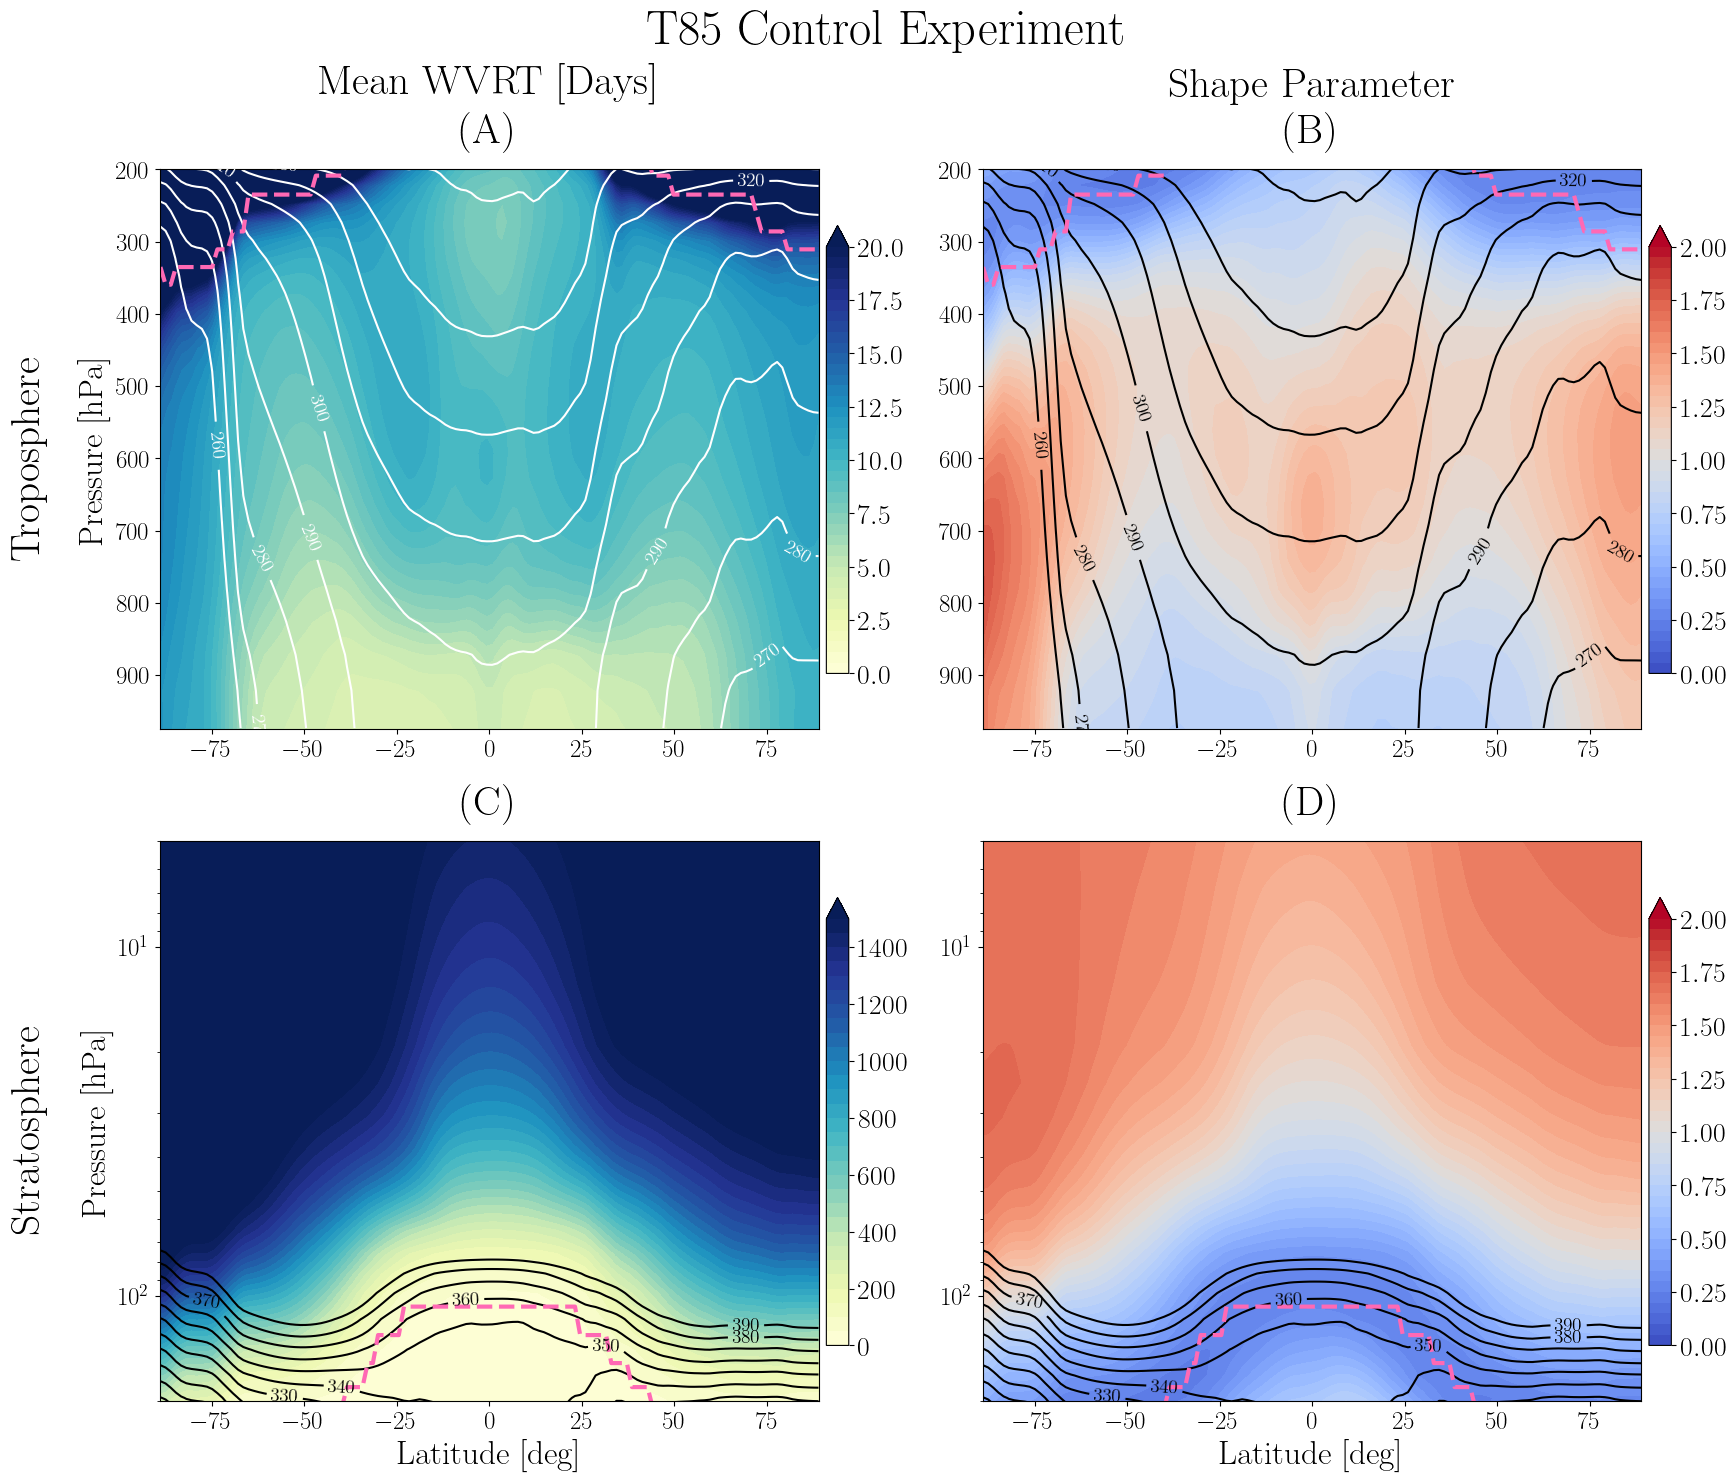

In [3]:



fig, ax = plt.subplots(2,2,figsize = (22,16),gridspec_kw={'hspace': 0.2,'wspace': 0.05})
ax_age = ax[0,0]

fig_,ax_age = dps.plot_age_moments_vertical_profile(20,mean,1,ps,pfull,lat,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu",
                                                    time_avg = True,lnP=False,custom = True, col = "white",ax = ax_age,steps=41)
ax_age.set_ylim(975,200)

ax_age_strat = ax[1,0]
fig_,ax_age_strat = dps.plot_age_moments_vertical_profile(1500,mean,1,ps,pfull,lat,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu",
                                                    time_avg = True,lnP=True,custom = True, ax = ax_age_strat,steps = 31)


ax_age_strat.set_ylim(200,5)

ax_shape = ax[0,1]

fig_,ax_shape = dps.plot_age_moments_vertical_profile(2,(24*60**2)*shape,1,ps,pfull,lat,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "coolwarm",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_shape,steps =41)

ax_shape.set_ylim(975,200)
ax_shape_strat = ax[1,1]
fig_,ax_shape_strat = dps.plot_age_moments_vertical_profile(2,(24*60**2)*shape,1,ps,pfull,lat,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "coolwarm",
                                                    time_avg = True,lnP=True,custom = True, ax = ax_shape_strat,col = "black",steps = 41)
ax_shape_strat.set_ylim(200,5)

plt.subplots_adjust(left=0.17) 
fig.text(0.11, 0.7, 'Troposphere', va='center', ha='center', rotation='vertical', fontsize=30)
fig.text(0.11, 0.28, 'Stratosphere', va='center', ha='center', rotation='vertical', fontsize=30)



letters = ["Mean WVRT [Days]\n (A)","(C)","Shape Parameter\n (B)","(D)"]
k=0
for i in range(2):
    for j in range(2):
        ax[j,i].set_title(letters[k],fontsize = 30,pad = 20)
        ax[j,i].plot(lat,trop_h_0,color = "hotpink",linewidth = 3,linestyle = "dashed")
        k+=1



ax_age.set_xlabel(" ")
ax_shape.set_xlabel(" ")

ax_shape.set_ylabel(" ")
ax_shape_strat.set_ylabel(" ")
fig.suptitle("T85 Control Experiment",fontsize = 35)
plt.savefig(f"{path_cur}/vert_profile_age_shape_T85.png",dpi = 250,bbox_inches = "tight")

**2d Maps**

Figure 3: Vertical Avg, 920hPa cross section and 600 hPa cross section
of mean WVRT and shape parameter

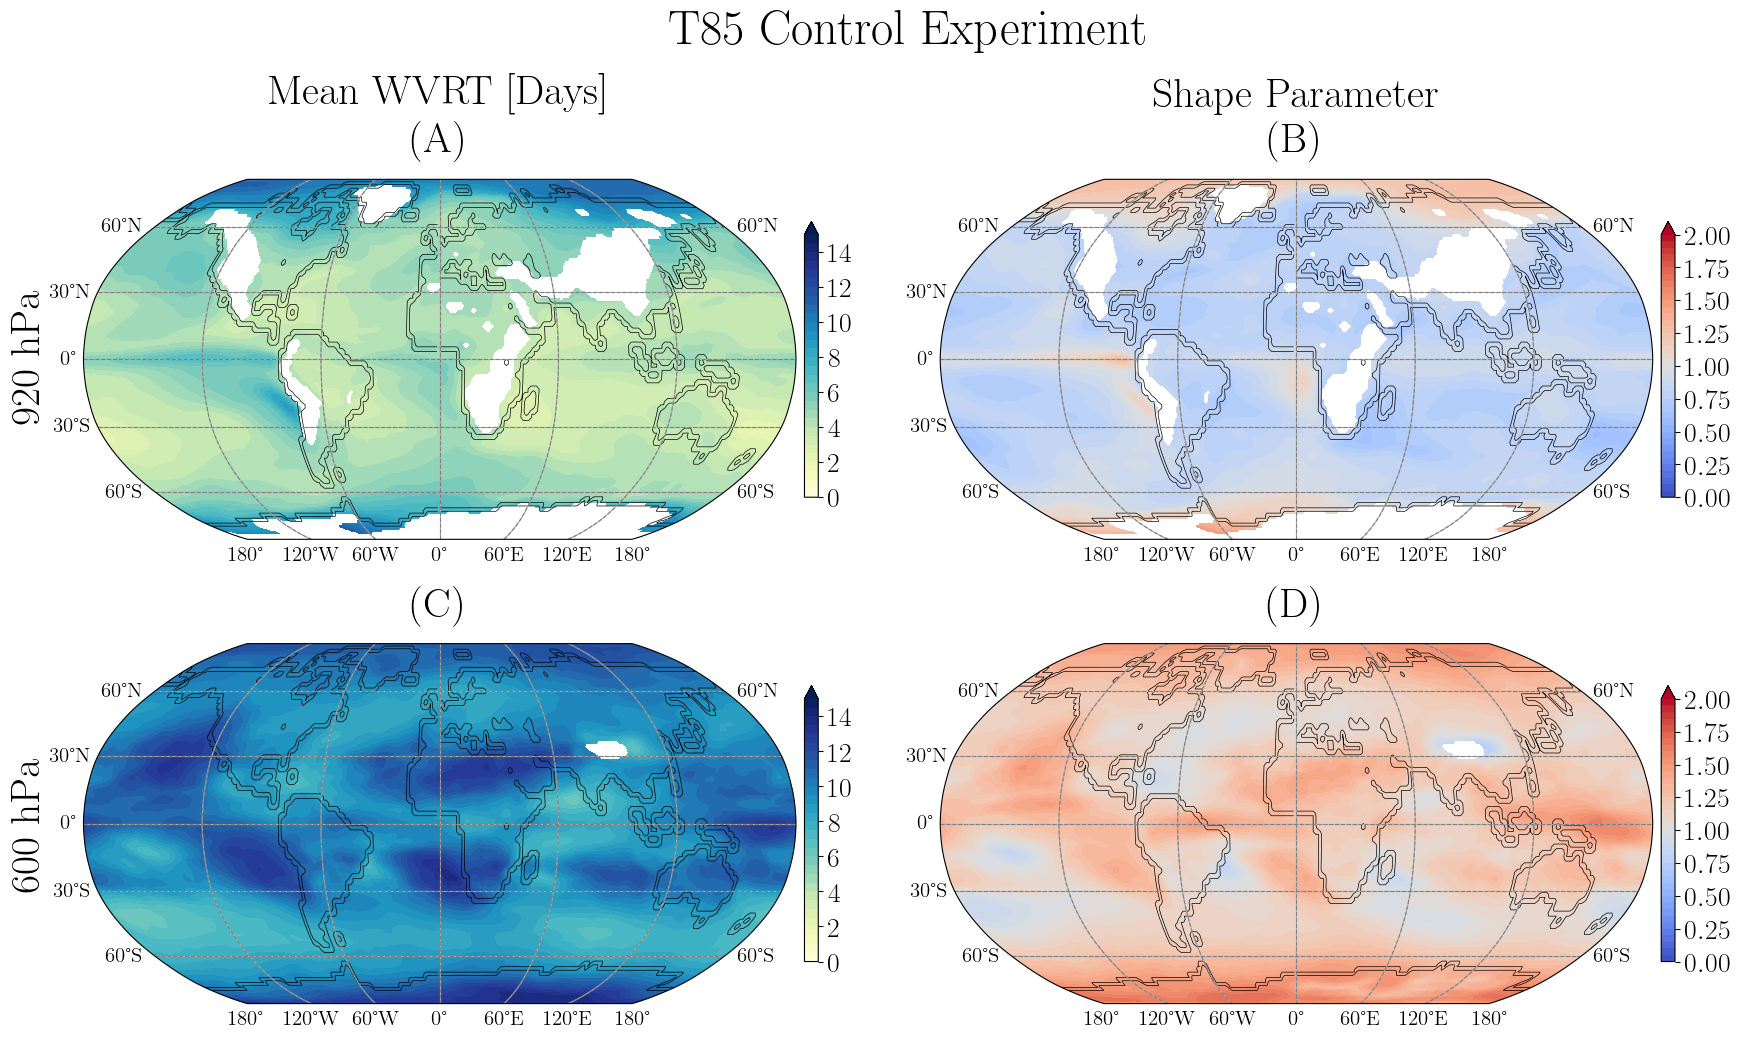

In [5]:
v_age_time = ds_dict["0"]["vert_time_mean"]
v_shape_time = ds_dict["0"]["vert_time_shape"]
v_std_time = ds_dict["0"]["v_std_time"]
lat = ds_dict["0"]["lat"]
lon = ds_dict["0"]["lon"]
ps = ds_dict["0"]["ps"]
pfull = ds_dict["0"]["pfull"]


fig, ax = plt.subplots(nrows=2, ncols=2, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (22,12),gridspec_kw={'hspace': 0.01,'wspace': 0.01})


ax_age_920 = ax[0,0]
dps.plot_age_moments_2d(920,15,mean,1,ps,lat,lon,pfull,fig, ax_age_920, time_avg = True,cmap = "YlGnBu",
                        title = "920 hPa",land_bool = True,land_mask = land_mask,steps = 31)

ax_age_920.set_title("920 hPa")
ax_age_920.set_xlabel("lon [deg]")
ax_age_920.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_920.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_age_600 = ax[1,0]
dps.plot_age_moments_2d(600,15,mean,1,ps,lat,lon,pfull,fig, ax_age_600, time_avg = True,cmap = "YlGnBu",
                        title = "600 hPa",land_bool = True,land_mask = land_mask,steps = 31)

ax_age_600.set_title("600 hPa")
ax_age_600.set_xlabel("lon [deg]")
ax_age_600.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_600.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False


ax_shape_920 = ax[0,1]
dps.plot_shape_param_2d(920,2,shape,ps,lat,lon,pfull,fig, ax_shape_920, time_avg = True,cmap = "coolwarm",
                        title = "920 hPa",land_bool = True,land_mask = land_mask,steps = 41)


ax_shape_920.set_xlabel("lon [deg]")
ax_shape_920.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_shape_920.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_shape_600 = ax[1,1]
dps.plot_shape_param_2d(600,2,shape,ps,lat,lon,pfull,fig, ax_shape_600, time_avg = True,cmap = "coolwarm",
                        title = "600 hPa",land_bool = True,land_mask = land_mask,steps = 41)




fig.text(0.1,0.3, '600 hPa', va='center', rotation='vertical',ha='center', fontsize=30)
fig.text(0.1,0.69, '920 hPa', va='center', ha='center',rotation='vertical', fontsize=30)

letters = ["Mean WVRT [Days]\n (A)","(C)","Shape Parameter\n (B)","(D)"]
k=0
for i in range(2):
    for j in range(2):
        ax[j,i].set_title(letters[k],pad = 20,fontsize = 30)
        k+=1

ax_shape_600.set_xlabel("lon [deg]")
ax_shape_600.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_shape_600.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
fig.suptitle("T85 Control Experiment",fontsize = 35)

plt.savefig(f"{path_cur}/maps_age_shape_T85.png",dpi = 250,bbox_inches = "tight")

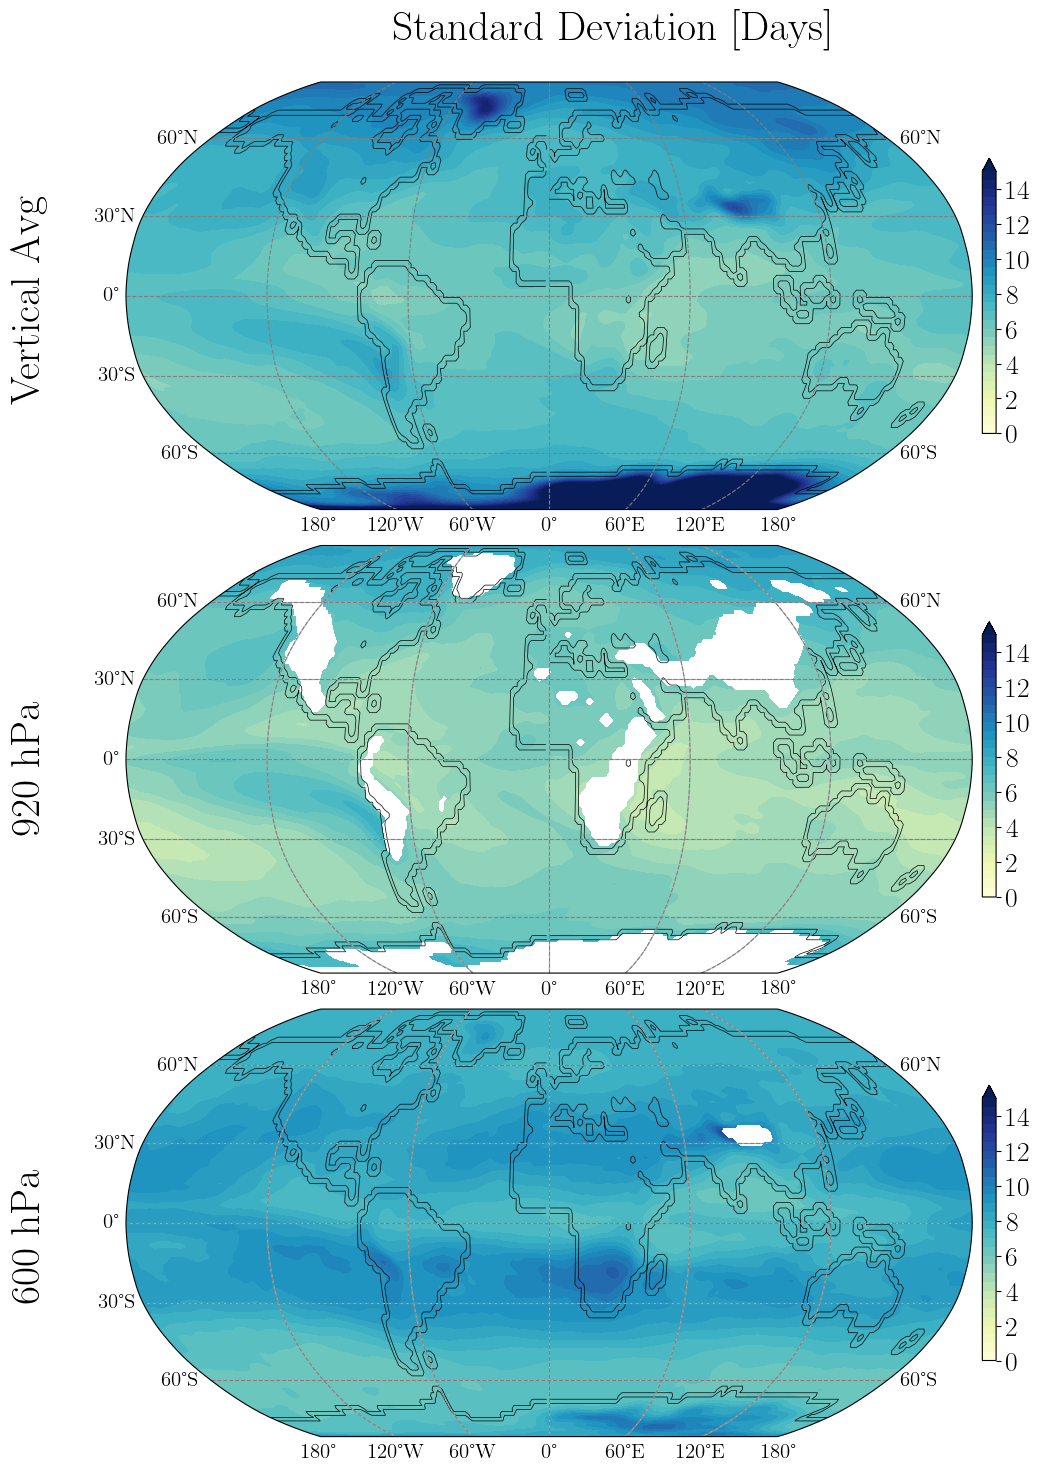

In [5]:
fig, ax = plt.subplots(nrows=3, ncols=1, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (13,18),gridspec_kw={'hspace': 0.01,'wspace': 0.01})

ax_age_vert = ax[0]
dps.plot_2d(v_std_time.values/(24*60**2),lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,15,31),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
ax_age_vert.set_title(" ")
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_age_920 = ax[1]
dps.plot_age_moments_2d(920,15,std,1,ps,lat,lon,pfull,fig, ax_age_920, time_avg = True,cmap = "YlGnBu",
                        title = " ",land_bool = True,land_mask = land_mask,steps = 31)

ax_age_920.set_title(" ")
ax_age_920.set_xlabel("lon [deg]")
ax_age_920.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_920.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_age_600 = ax[2]
dps.plot_age_moments_2d(600,15,std,1,ps,lat,lon,pfull,fig, ax_age_600, time_avg = True,cmap = "YlGnBu",
                        title = " ",land_bool = True,land_mask = land_mask,steps = 31)

ax_age_600.set_title(" ")
ax_age_600.set_xlabel("lon [deg]")
ax_age_600.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_600.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False


fig.text(0.5, 0.9, 'Standard Deviation [Days]', va='center', ha='center', fontsize=30)

fig.text(0.05,0.23, '600 hPa', va='center', rotation='vertical',ha='center', fontsize=30)
fig.text(0.05,0.49, '920 hPa', va='center', ha='center',rotation='vertical', fontsize=30)
fig.text(0.05,0.75 , 'Vertical Avg', va='center', ha='center',rotation='vertical', fontsize=30)


plt.savefig(f"{path_cur}/maps_std_T85.png",dpi = 250,bbox_inches = "tight")

**Age of precipitation**

Figure 4: Age of precip

In [6]:
precip_age = ds_dict["0"]["precip_age"]
anomally_precip_age = ds_dict["2"]["precip_age"] - ds_dict["0"]["precip_age"]

fig, ax = plt.subplots(nrows=1, ncols=1, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (12,5.5))

ax_age_vert = ax
dps.plot_2d(precip_age.values/(24*60**2),lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,15,31),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
#ax_age_vert.set_title("Control Experiment",fontsize = 25,pad = 10)

# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

fig.suptitle("Mean Age of Precipitation [Days]",fontsize = 35)
plt.savefig(f"{path_cur}/map_precip_age_T85.png",dpi = 250,bbox_inches = "tight")

KeyError: 'precip_age'